# Taller 1 — Supervisión de contratación pública de bienes (SECOP II)
**MINE-4101: Ciencia de Datos Aplicada — Semestre 2026-20**

**Integrantes:** _(completar nombres)_

**Objetivo:** Analizar los contratos de compra de bienes (compraventa y suministros) firmados por entidades públicas colombianas entre 2019 y 2025, para ayudar a la oficina de control interno a **focalizar su supervisión** hacia los contratos con mayor riesgo de desviarse del plan inicial (adiciones de plazo, ejecución presupuestal incompleta o cierre sin liquidar).

**Fuente:** SECOP II — Sistema Electrónico de Contratación Pública.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
RNG = 42


## 1. Entendimiento inicial de datos (20%)

Cargamos el dataset y revisamos su estructura general: dimensiones, tipos de datos, valores nulos y consistencia de las columnas clave.

In [2]:
df_raw = pd.read_parquet('../data/secop_bienes.parquet')
print(f"Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones: 196,391 filas x 36 columnas


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,17897916.0,17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.0,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.0,11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...


In [3]:
df_raw.dtypes.to_frame('tipo_de_dato')

,tipo_de_dato
id_contrato,str
nombre_entidad,str
departamento,str
ciudad,str
orden,str
sector,str
rama,str
entidad_centralizada,str
tipo_de_contrato,str
modalidad_de_contratacion,str


In [4]:
# Valores nulos por columna (%)
nulos = (df_raw.isna().mean()*100).round(2).sort_values(ascending=False)
nulos[nulos>0]

fecha_de_inicio_del_contrato    1.24
dtype: float64

Solo `fecha_de_inicio_del_contrato` presenta nulos explícitos (~1.2%). Sin embargo, varias columnas categóricas usan la etiqueta literal **"No Definido"** o **"No aplica"** como un nulo disfrazado — se tratan más adelante como categoría de "dato no reportado", no se imputan, porque en datos administrativos su ausencia es en sí misma informativa (ej. una entidad que no diligencia el destino del gasto).

### Selección de los 5 atributos más relevantes

Elegimos estos 5 atributos porque son exactamente los que menciona el enunciado del taller como relevantes para detectar desviaciones y porque, según nuestra exploración inicial, son los que más varianza explican en los indicadores de desviación (ver sección 3):

1. **`valor_del_contrato`** — tamaño económico del contrato (numérica continua).
2. **`modalidad_de_contratacion`** — mecanismo de selección del proveedor (categórica).
3. **`sector`** — sector administrativo al que pertenece la entidad contratante (categórica).
4. **`dias_adicionados`** — días de prórroga acumulados al contrato (numérica discreta, proxy directo de desviación de plazo).
5. **`destino_gasto`** — funcionamiento vs. inversión (categórica).

A continuación, el análisis univariado de cada uno.

In [5]:
print(df_raw['valor_del_contrato'].describe().apply(lambda x: f"{x:,.0f}"))
print()
print("Contratos con valor <= 0:", (df_raw['valor_del_contrato']<=0).sum())
p999 = df_raw.loc[df_raw['valor_del_contrato']>0,'valor_del_contrato'].quantile(0.999)
print(f"Percentil 99.9: {p999:,.0f}  |  Máximo: {df_raw['valor_del_contrato'].max():,.0f}")
print("Contratos por encima del percentil 99.9:", (df_raw['valor_del_contrato']>p999).sum())

count                   196,391
mean             65,824,255,028
std          29,015,352,967,837
min                           0
25%                  12,021,214
50%                  33,600,000
75%                 100,000,000
max      12,858,450,316,000,000
Name: valor_del_contrato, dtype: str

Contratos con valor <= 0: 188
Percentil 99.9: 31,000,990,678  |  Máximo: 12,858,450,316,000,000
Contratos por encima del percentil 99.9: 197


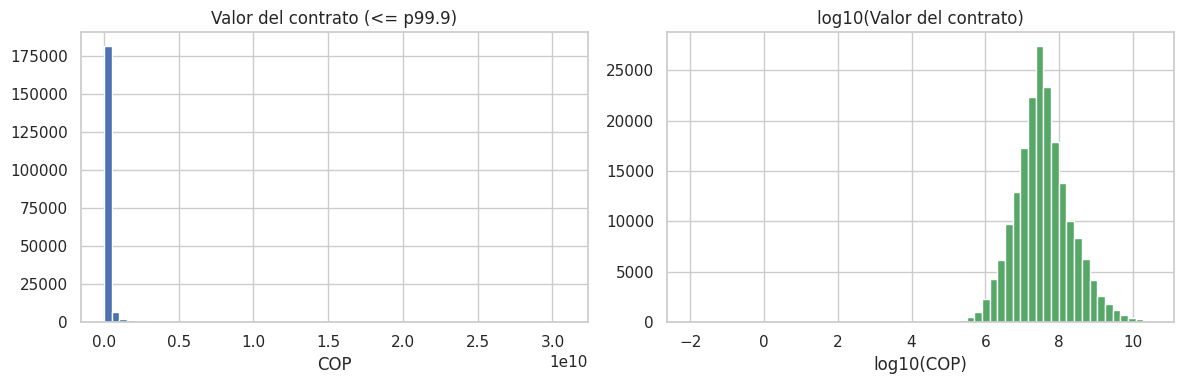

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
vals = df_raw.loc[(df_raw['valor_del_contrato']>0)&(df_raw['valor_del_contrato']<=p999),'valor_del_contrato']
axes[0].hist(vals, bins=60, color='#4C72B0')
axes[0].set_title('Valor del contrato (<= p99.9)')
axes[0].set_xlabel('COP')
axes[1].hist(np.log10(vals), bins=60, color='#55A868')
axes[1].set_title('log10(Valor del contrato)')
axes[1].set_xlabel('log10(COP)')
plt.tight_layout(); plt.show()

**Hallazgo:** la distribución de `valor_del_contrato` es extremadamente asimétrica a la derecha (típico de montos monetarios), con una mediana de ~\$33.6M COP frente a una media de ~\$65.8 mil millones — completamente distorsionada por un puñado de valores claramente erróneos (uno de ellos supera los 12 mil billones de COP, imposible para un contrato de bienes). En log10 la distribución es mucho más cercana a una normal, confirmando que el problema es de escala/outliers, no de la variable en sí.

modalidad_de_contratacion
Mínima cuantía                                                 60.0
Selección abreviada subasta inversa                            16.8
Contratación régimen especial                                   9.8
Selección Abreviada de Menor Cuantía                            4.5
Contratación régimen especial (con ofertas)                     3.1
Contratación Directa (con ofertas)                              2.5
Contratación directa                                            2.0
Licitación pública                                              1.2
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes     0.1
Name: count, dtype: float64


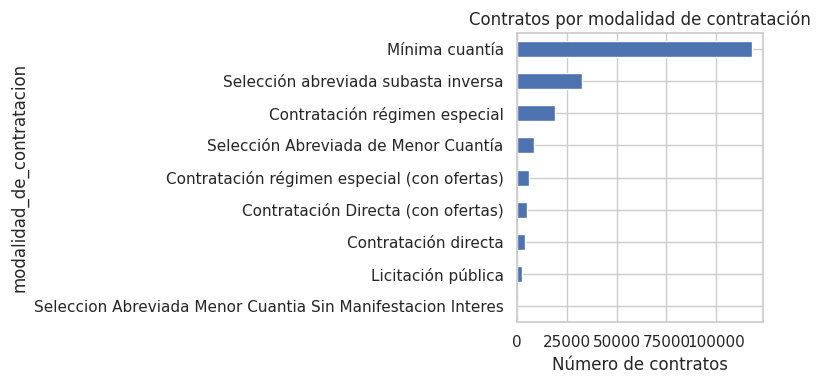

In [7]:
mod_counts = df_raw['modalidad_de_contratacion'].value_counts()
print((mod_counts/len(df_raw)*100).round(1))

fig, ax = plt.subplots(figsize=(8,4))
mod_counts.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Número de contratos'); ax.set_title('Contratos por modalidad de contratación')
plt.tight_layout(); plt.show()

**Hallazgo:** el 60% de los contratos se firman por **Mínima cuantía**, la modalidad más simple/ágil reservada para montos pequeños, seguida de subasta inversa (16.8%) y régimen especial (9.8%). La alta concentración en mínima cuantía es esperable dado que el dataset cubre *bienes* (compras rutinarias), pero implica que el volumen de supervisión manual no puede centrarse solo en contratos grandes/licitados: hay que usar reglas automatizadas para el grueso del universo.

sector
Servicio Público                    37390
defensa                             34585
No aplica/No pertenece              24465
Salud y Protección Social           22037
Ley de Justicia                     20377
Trabajo                             14759
Educación Nacional                  10231
Ambiente y Desarrollo Sostenible     8109
Transporte                           4655
Cultura                              2792
Name: count, dtype: int64


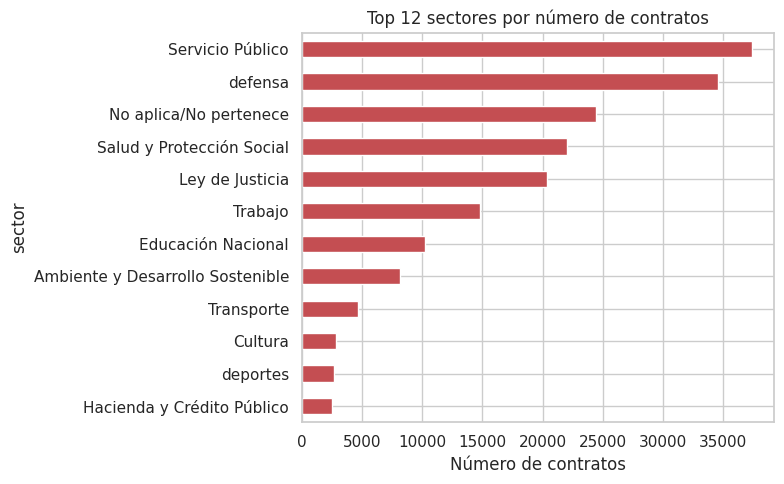

In [8]:
sec_counts = df_raw['sector'].value_counts()
print(sec_counts.head(10))

fig, ax = plt.subplots(figsize=(8,5))
sec_counts.head(12).sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_xlabel('Número de contratos'); ax.set_title('Top 12 sectores por número de contratos')
plt.tight_layout(); plt.show()

**Hallazgo:** los sectores con más contratos de bienes son *Servicio Público* (19%), *defensa* (17.6%) y *Salud y Protección Social* (11.2%). El sector *defensa* concentra fuerte peso en entidades como el Ejército, lo cual es relevante porque, como se ve en la sección 3, estos sectores muestran patrones de desviación muy distintos entre sí.

count    196391.000000
mean          5.107485
std          40.662426
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       14276.000000
Name: dias_adicionados, dtype: float64

Contratos con dias_adicionados > 0: 18671 (9.5%)


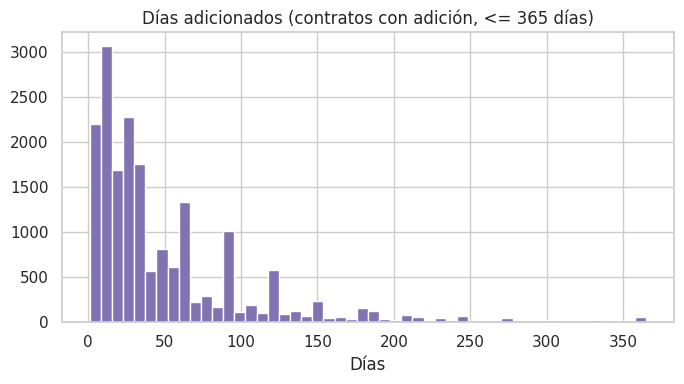

In [9]:
print(df_raw['dias_adicionados'].describe())
print()
print("Contratos con dias_adicionados > 0:", (df_raw['dias_adicionados']>0).sum(),
      f"({(df_raw['dias_adicionados']>0).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7,4))
sub = df_raw.loc[(df_raw['dias_adicionados']>0)&(df_raw['dias_adicionados']<=365),'dias_adicionados']
ax.hist(sub, bins=50, color='#8172B2')
ax.set_title('Días adicionados (contratos con adición, <= 365 días)')
ax.set_xlabel('Días'); plt.tight_layout(); plt.show()

**Hallazgo:** solo el 9.5% de los contratos recibe adición de plazo, pero cuando ocurre, la mediana de la adición se concentra en pocos meses — con una cola larga de casos extremos (hasta 14,276 días, es decir, ~39 años, casi con certeza un error de digitación o un caso atípico que merece revisión manual puntual). `dias_adicionados` es nuestro proxy más directo de "desviación de plazo".

destino_gasto
Funcionamiento    59.6
Inversión         39.9
No aplica          0.3
No Definido        0.2
Name: count, dtype: float64


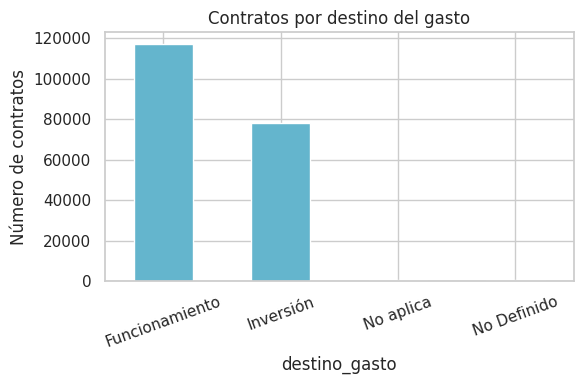

In [10]:
dg = df_raw['destino_gasto'].value_counts()
print((dg/len(df_raw)*100).round(1))

fig, ax = plt.subplots(figsize=(6,4))
dg.plot(kind='bar', ax=ax, color='#64B5CD')
ax.set_ylabel('Número de contratos'); ax.set_title('Contratos por destino del gasto')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

**Hallazgo:** 59.6% de los contratos son de *Funcionamiento* y 39.9% de *Inversión*. Esta distinción importa porque los recursos de inversión suelen tener reglas de ejecución y liquidación más estrictas (y en general, mayor escrutinio político), lo que hipotetizamos que se asocia con distinto comportamiento de desviación.

### Problemas de calidad de datos identificados y tratamiento

| Problema | Magnitud | Tratamiento |
|---|---|---|
| `valor_del_contrato` ≤ 0 | 188 contratos (0.10%) | Se excluyen de los análisis basados en valor (no son compras reales válidas) |
| `valor_del_contrato` con outliers extremos de digitación (ej. 1.28×10¹⁶) | 197 contratos por encima del percentil 99.9 | Se excluyen del análisis cuantitativo de valor (se documentan como casos a revisar manualmente, no se imputan ni se inventan valores) |
| `fecha_de_fin_del_contrato` anterior a `fecha_de_inicio_del_contrato` | 125 contratos (0.06%) | Se excluyen de los análisis que usan fechas/duración, por inconsistencia lógica |
| `fecha_de_inicio_del_contrato` nula | ~1.2% | Se conservan (no afecta los indicadores usados); se excluyen únicamente de cálculos que requieran esa fecha puntual |
| Categorías "No Definido" / "No aplica" en columnas categóricas (`sector`, `destino_gasto`, `habilita_pago_adelantado`, etc.) | Variable por columna (0.2%–14.5%) | Se conservan como categoría propia ("no reportado"), no se imputan — su ausencia es informativa en un dataset administrativo |
| Ventana temporal de 7 años no directamente comparable (contratos recientes no han tenido tiempo de liquidarse/cerrarse) | Ver sección 3 | Se define una ventana de análisis explícita para los indicadores de desviación que dependen del ciclo de vida del contrato |

Ningún registro se imputa numéricamente (no se rellenan valores faltantes con medias/medianas): en datos de contratación pública, "inventar" un valor de contrato o una fecha puede introducir sesgos que llevarían a conclusiones de supervisión equivocadas. Preferimos excluir explícitamente y documentar cuántos registros se pierden en cada paso.

In [11]:
# Aplicamos la limpieza descrita arriba y creamos el dataset de trabajo (dfc)
dfc = df_raw.copy()
dfc = dfc[dfc['valor_del_contrato'] > 0]
p999 = dfc['valor_del_contrato'].quantile(0.999)
dfc = dfc[dfc['valor_del_contrato'] <= p999]
dfc = dfc[dfc['fecha_de_fin_del_contrato'] >= dfc['fecha_de_inicio_del_contrato']]
dfc['anio_firma'] = dfc['fecha_de_firma'].dt.year

print(f"Registros originales: {len(df_raw):,}")
print(f"Registros tras limpieza: {len(dfc):,}  ({len(dfc)/len(df_raw)*100:.1f}% retenido)")

Registros originales: 196,391
Registros tras limpieza: 193,445  (98.5% retenido)


## 2. Estrategia de análisis (15%)

Definimos la **desviación de un contrato** operacionalmente a partir de tres indicadores directamente derivables del dataset, cada uno asociado a uno de los síntomas descritos en el contexto de negocio: (i) **adición de plazo** (`dias_adicionados > 0`), que refleja incumplimiento del cronograma inicial; (ii) **ejecución presupuestal incompleta** (`valor_pagado` < 90% de `valor_del_contrato` en contratos ya finalizados), que refleja que el presupuesto comprometido no se ejecutó; y (iii) **cierre sin liquidar** (`liquidacion == "No"` en contratos con estado `terminado`/`Cerrado`), que refleja procesos administrativos que quedan inconclusos. No los combinamos en un único índice porque, como se muestra más adelante, son prácticamente independientes entre sí (correlación < 0.05) y cada uno responde a una causa distinta — mezclarlos en un solo "score" oscurecería cuál factor está fallando y le restaría utilidad accionable a la oficina de control interno.

Como los indicadores (ii) y (iii) solo pueden observarse una vez el contrato termina su ciclo de vida, y los contratos firmados en 2024–2025 aún no han tenido tiempo suficiente para cerrarse (verificado empíricamente: la tasa de contratos "finalizados" cae de ~53-60% en 2019-2023 a 36.6% en 2025), restringimos el análisis de estos dos indicadores a contratos **firmados entre 2019 y 2023**, evitando así una censura por derecha que subestimaría artificialmente el problema en los años más recientes. El indicador de plazo adicionado se calcula sobre esa misma ventana para todos los contratos (finalizados o no), ya que una adición de plazo, una vez ocurre, queda registrada independientemente del estado actual del contrato.

Con esta base, calculamos estadísticos descriptivos univariados (sección 1) y luego cruzamos cada indicador de desviación con los atributos estructurales del contrato — modalidad de contratación, sector, orden de la entidad, destino del gasto, tipo de proveedor (PyME) y valor del contrato — usando **pruebas de hipótesis explícitas**: chi-cuadrado de independencia para pares categóricos, U de Mann-Whitney para comparar `valor_del_contrato` (variable con distribución muy asimétrica, por lo que evitamos t-test paramétrico) entre grupos con y sin desviación, y Kruskal-Wallis para comparar `dias_adicionados` entre las distintas modalidades. Dado el tamaño de muestra (>60,000 contratos en la ventana de análisis), casi cualquier diferencia resulta estadísticamente significativa; por eso complementamos cada prueba significativa con el tamaño de efecto (V de Cramér) para distinguir significancia estadística de relevancia práctica antes de traducir los hallazgos en criterios de focalización.

## 3. Desarrollo de la estrategia (40%)

### 3.1 Construcción de indicadores de desviación

In [12]:
dfc['exec_ratio'] = dfc['valor_pagado'] / dfc['valor_del_contrato']
dfc['plazo_adicionado'] = dfc['dias_adicionados'] > 0
dfc['finalizado'] = dfc['estado_contrato'].isin(['terminado', 'Cerrado'])
dfc['no_liquidado_tras_fin'] = dfc['finalizado'] & (dfc['liquidaci_n'] == 'No')
dfc['ejecucion_incompleta'] = dfc['finalizado'] & (dfc['exec_ratio'] < 0.9)

print("Tasas globales (todo el dataset limpio, sin restringir ventana temporal):")
print(f"  Plazo adicionado:        {dfc['plazo_adicionado'].mean()*100:.1f}%")
fin_all = dfc[dfc['finalizado']]
print(f"  No liquidado (finaliz.): {fin_all['no_liquidado_tras_fin'].mean()*100:.1f}%")
print(f"  Ejecución incompleta:    {fin_all['ejecucion_incompleta'].mean()*100:.1f}%")

Tasas globales (todo el dataset limpio, sin restringir ventana temporal):
  Plazo adicionado:        9.6%
  No liquidado (finaliz.): 55.4%
  Ejecución incompleta:    46.7%


### 3.2 Verificación de censura por derecha y definición de la ventana de análisis

anio_firma
2019    52.8
2020    58.3
2021    59.7
2022    59.9
2023    53.7
2024    53.3
2025    36.6
Name: finalizado, dtype: float64


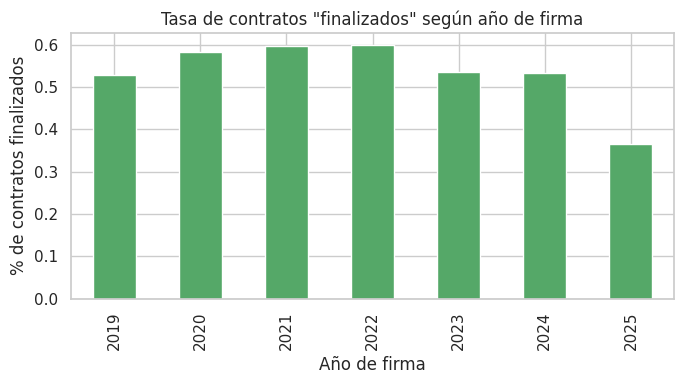

In [13]:
tasa_finalizado_por_anio = dfc.groupby('anio_firma')['finalizado'].mean()
print((tasa_finalizado_por_anio*100).round(1))

fig, ax = plt.subplots(figsize=(7,4))
tasa_finalizado_por_anio.plot(kind='bar', ax=ax, color='#55A868')
ax.set_ylabel('% de contratos finalizados'); ax.set_xlabel('Año de firma')
ax.set_title('Tasa de contratos "finalizados" según año de firma')
plt.tight_layout(); plt.show()

Se confirma la caída en 2025 (36.6% vs. ~53-60% en años previos): los contratos firmados en 2025 aún no han tenido tiempo de completar su ciclo. Definimos la **ventana de análisis** como contratos firmados entre 2019 y 2023 para los indicadores dependientes del ciclo de vida.

In [14]:
window = dfc[dfc['anio_firma'] <= 2023].copy()
window_fin = window[window['finalizado']].copy()
print(f"N ventana de análisis (2019-2023): {len(window):,}")
print(f"N finalizados dentro de la ventana: {len(window_fin):,}")
print()
print("Correlación entre los 3 indicadores (confirmando que son casi independientes):")
print(window_fin[['plazo_adicionado','no_liquidado_tras_fin','ejecucion_incompleta']].astype(int).corr().round(2))

N ventana de análisis (2019-2023): 119,748
N finalizados dentro de la ventana: 68,175

Correlación entre los 3 indicadores (confirmando que son casi independientes):
                       plazo_adicionado  no_liquidado_tras_fin  ejecucion_incompleta
plazo_adicionado                   1.00                   0.01                  0.03
no_liquidado_tras_fin              0.01                   1.00                  0.02
ejecucion_incompleta               0.03                   0.02                  1.00


### 3.3 Pruebas de hipótesis

In [15]:
def prueba_chi2(data, col, target, label, min_n=50):
    tab = pd.crosstab(data[col], data[target])
    tab = tab[tab.sum(axis=1) >= min_n]
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    n = tab.sum().sum()
    r, k = tab.shape
    cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    tasa = data.groupby(col)[target].agg(['mean', 'count'])
    tasa = tasa[tasa['count'] >= min_n].sort_values('mean', ascending=False)
    sig = "SIGNIFICATIVO (p<0.05)" if p < 0.05 else "NO significativo (p>=0.05)"
    print(f"### {label}")
    print(f"chi2={chi2:,.1f}  dof={dof}  p={p:.2e}  ->  {sig}   |   V de Cramér = {cramers_v:.3f}")
    display((tasa['mean']*100).round(1).rename('% con desviación'))
    print()
    return {'label': label, 'chi2': chi2, 'p': p, 'cramers_v': cramers_v}

resultados = []

**Bloque A — Adición de plazo** (todos los contratos con tiempo suficiente para observarse, ventana 2019-2023).

*H0: la modalidad/sector/orden de contratación es independiente de que el contrato reciba adición de plazo.*

In [16]:
resultados.append(prueba_chi2(window, 'modalidad_de_contratacion', 'plazo_adicionado',
                               'H1a — Modalidad de contratación vs. plazo adicionado'))
resultados.append(prueba_chi2(window, 'sector', 'plazo_adicionado',
                               'H1b — Sector vs. plazo adicionado'))
resultados.append(prueba_chi2(window, 'orden', 'plazo_adicionado',
                               'H1c — Orden de la entidad (Nacional/Territorial) vs. plazo adicionado'))

### H1a — Modalidad de contratación vs. plazo adicionado
chi2=1,577.4  dof=8  p=0.00e+00  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.115


modalidad_de_contratacion
Licitación pública                                             19.5
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes    15.2
Contratación régimen especial (con ofertas)                    11.6
Selección abreviada subasta inversa                            11.2
Selección Abreviada de Menor Cuantía                           11.1
Contratación Directa (con ofertas)                              6.9
Contratación directa                                            6.8
Mínima cuantía                                                  5.5
Contratación régimen especial                                   4.1
Name: % con desviación, dtype: float64


### H1b — Sector vs. plazo adicionado
chi2=780.5  dof=24  p=2.72e-149  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.081


sector
Trabajo                                               12.2
Minas y Energía                                       11.9
interior                                              10.9
Información Estadística                               10.7
Inclusión Social y Reconciliación                      8.7
Servicio Público                                       8.5
Tecnologías de la Información y las Comunicaciones     7.9
Educación Nacional                                     7.5
Cultura                                                7.4
Salud y Protección Social                              7.1
No aplica/No pertenece                                 6.9
Planeación                                             6.8
agricultura                                            6.7
Vivienda, Ciudad y Territorio                          6.7
Transporte                                             6.4
defensa                                                6.4
Ambiente y Desarrollo Sostenible                 


### H1c — Orden de la entidad (Nacional/Territorial) vs. plazo adicionado
chi2=29.4  dof=2  p=4.09e-07  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.016


orden
Territorial             7.4
Nacional                6.9
Corporación Autónoma    4.3
Name: % con desviación, dtype: float64

**Interpretación:** se rechaza H0 en los tres casos (p ≪ 0.05). La modalidad **Licitación pública** (19.5%) y las modalidades de selección abreviada (~11%) concentran mucho más riesgo de adición de plazo que **Mínima cuantía** (5.5%) — esperable, porque los procesos más grandes/complejos son más susceptibles a imprevistos. El sector **Trabajo** y **Minas y Energía** muestran las tasas más altas (~12%). El efecto de `orden` es significativo pero con V de Cramér pequeño, es decir, estadísticamente real pero de baja relevancia práctica por sí solo.

**Bloque B — Cierre sin liquidar** (solo contratos finalizados, ventana 2019-2023).

*H0: la modalidad/orden/destino del gasto es independiente de que el contrato finalizado quede sin liquidar.*

In [17]:
resultados.append(prueba_chi2(window_fin, 'modalidad_de_contratacion', 'no_liquidado_tras_fin',
                               'H2a — Modalidad de contratación vs. no liquidado tras finalizar'))
resultados.append(prueba_chi2(window_fin, 'orden', 'no_liquidado_tras_fin',
                               'H2b — Orden de la entidad vs. no liquidado tras finalizar'))
resultados.append(prueba_chi2(window_fin, 'destino_gasto', 'no_liquidado_tras_fin',
                               'H2c — Destino del gasto vs. no liquidado tras finalizar'))

### H2a — Modalidad de contratación vs. no liquidado tras finalizar
chi2=2,595.2  dof=8  p=0.00e+00  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.195


modalidad_de_contratacion
Contratación régimen especial (con ofertas)                    88.1
Contratación régimen especial                                  78.0
Contratación directa                                           69.0
Mínima cuantía                                                 60.1
Contratación Directa (con ofertas)                             52.1
Selección Abreviada de Menor Cuantía                           48.4
Selección abreviada subasta inversa                            47.9
Licitación pública                                             43.5
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes    25.2
Name: % con desviación, dtype: float64


### H2b — Orden de la entidad vs. no liquidado tras finalizar
chi2=1,276.5  dof=2  p=6.49e-278  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.137


orden
Territorial             67.5
Corporación Autónoma    60.3
Nacional                53.7
Name: % con desviación, dtype: float64


### H2c — Destino del gasto vs. no liquidado tras finalizar
chi2=524.2  dof=3  p=2.75e-113  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.088


destino_gasto
No aplica         97.7
Inversión         63.8
No Definido       58.4
Funcionamiento    56.3
Name: % con desviación, dtype: float64

**Interpretación:** se rechaza H0 en los tres casos. Este es el indicador con mayor magnitud global (59.2% de contratos finalizados no liquidados) y también el que muestra la brecha más marcada por modalidad: **Contratación régimen especial (con ofertas)** llega a 88.1% sin liquidar, frente a 25.2% en "Selección Abreviada Menor Cuantía Sin Manifestación de Interés". Los contratos **Territoriales** (67.5%) están mucho peor que los **Nacionales** (53.7%) — consistente con la percepción de que las entidades territoriales tienen menor capacidad administrativa para el cierre formal de contratos. Los contratos de **Inversión** (63.8%) quedan sin liquidar más que los de **Funcionamiento** (56.3%), contrario a lo que uno esperaría dado el mayor escrutinio nominal sobre inversión — posible foco de atención para la oficina de control.

**Bloque C — Ejecución presupuestal incompleta** (pago < 90% del valor, solo contratos finalizados, ventana 2019-2023).

*H0: la modalidad/sector/tipo de proveedor es independiente de que el contrato finalizado quede con ejecución incompleta.*

In [18]:
resultados.append(prueba_chi2(window_fin, 'modalidad_de_contratacion', 'ejecucion_incompleta',
                               'H3a — Modalidad de contratación vs. ejecución incompleta'))
resultados.append(prueba_chi2(window_fin, 'sector', 'ejecucion_incompleta',
                               'H3b — Sector vs. ejecución incompleta'))
resultados.append(prueba_chi2(window_fin, 'es_pyme', 'ejecucion_incompleta',
                               'H3c — Proveedor PyME vs. ejecución incompleta'))

### H3a — Modalidad de contratación vs. ejecución incompleta
chi2=2,536.1  dof=8  p=0.00e+00  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.193


modalidad_de_contratacion
Contratación régimen especial (con ofertas)                    89.2
Contratación régimen especial                                  69.7
Contratación directa                                           61.5
Selección Abreviada de Menor Cuantía                           59.0
Licitación pública                                             54.1
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes    52.1
Contratación Directa (con ofertas)                             50.8
Selección abreviada subasta inversa                            48.0
Mínima cuantía                                                 46.7
Name: % con desviación, dtype: float64


### H3b — Sector vs. ejecución incompleta
chi2=7,863.2  dof=23  p=0.00e+00  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.340


sector
Relaciones Exteriores                                 97.4
Minas y Energía                                       86.2
Salud y Protección Social                             79.9
Ciencia Tecnología                                    72.4
Industria                                             72.2
Transporte                                            71.5
agricultura                                           68.3
Presidencia de la República                           66.9
Tecnologías de la Información y las Comunicaciones    63.1
Vivienda, Ciudad y Territorio                         63.0
Inclusión Social y Reconciliación                     61.1
defensa                                               59.5
No aplica/No pertenece                                49.1
interior                                              48.8
Información Estadística                               45.5
Servicio Público                                      45.3
Ambiente y Desarrollo Sostenible                 


### H3c — Proveedor PyME vs. ejecución incompleta
chi2=398.1  dof=1  p=1.39e-88  ->  SIGNIFICATIVO (p<0.05)   |   V de Cramér = 0.076


es_pyme
No    58.7
Si    49.3
Name: % con desviación, dtype: float64

**Interpretación:** se rechaza H0 en los tres casos. `sector` es el atributo con el efecto más fuerte de todo el análisis (V de Cramér ≈ 0.34): sectores como **Relaciones Exteriores** (97.4%) y **Minas y Energía** (86.2%) casi siempre cierran con ejecución incompleta, mientras que **Trabajo** (14.4%) lo hace muy poco — sugiere que el sector es, junto con la modalidad, el criterio más útil para focalizar supervisión. Los proveedores **no-PyME** muestran mayor tasa de ejecución incompleta (58.7% vs. 49.3% en PyME), aunque con efecto pequeño (V≈0.08).

**Bloque D — Valor del contrato (variable numérica) vs. cada indicador de desviación**

*H0: la mediana de `valor_del_contrato` es igual entre contratos con y sin desviación (prueba U de Mann-Whitney, por la fuerte asimetría de la variable).*

In [19]:
for outcome, label, data in [
    ('plazo_adicionado', 'H4a — Valor del contrato vs. plazo adicionado', window),
    ('no_liquidado_tras_fin', 'H4b — Valor del contrato vs. no liquidado tras finalizar', window_fin),
    ('ejecucion_incompleta', 'H4c — Valor del contrato vs. ejecución incompleta', window_fin),
]:
    g1 = data.loc[data[outcome], 'valor_del_contrato']
    g0 = data.loc[~data[outcome], 'valor_del_contrato']
    u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    sig = "SIGNIFICATIVO" if p < 0.05 else "NO significativo"
    print(f"{label}")
    print(f"  mediana (con desviación) = {g1.median():>15,.0f} COP")
    print(f"  mediana (sin desviación) = {g0.median():>15,.0f} COP")
    print(f"  U={u:,.0f}  p={p:.2e}  -> {sig}\n")

H4a — Valor del contrato vs. plazo adicionado
  mediana (con desviación) =      71,400,000 COP
  mediana (sin desviación) =      29,000,000 COP
  U=620,360,186  p=0.00e+00  -> SIGNIFICATIVO



H4b — Valor del contrato vs. no liquidado tras finalizar
  mediana (con desviación) =      27,982,365 COP
  mediana (sin desviación) =      42,000,000 COP
  U=476,227,280  p=1.83e-248  -> SIGNIFICATIVO

H4c — Valor del contrato vs. ejecución incompleta
  mediana (con desviación) =      36,367,862 COP
  mediana (sin desviación) =      29,820,485 COP
  U=616,132,308  p=1.77e-43  -> SIGNIFICATIVO



**Interpretación:** los contratos con **plazo adicionado** tienen una mediana de valor más del doble que los que no lo tienen (\$71.4M vs. \$29.0M) — coherente con que los contratos más grandes son más complejos de ejecutar en el plazo inicial. En cambio, los contratos **no liquidados** tienden a ser de *menor* valor (\$28.0M vs. \$42.0M) — contraintuitivo, y sugiere que el cierre sin liquidar es más un problema de **volumen/capacidad administrativa** en contratos pequeños y numerosos que de complejidad en contratos grandes.

**Bloque E — Días adicionados (numérica continua) por modalidad de contratación**

*H0: la distribución de `dias_adicionados` es igual entre todas las modalidades (Kruskal-Wallis, por no-normalidad).*

In [20]:
grupos = [g['dias_adicionados'].values for _, g in window.groupby('modalidad_de_contratacion') if len(g) >= 50]
kw = stats.kruskal(*grupos)
print(f"H5 — Kruskal-Wallis: H={kw.statistic:,.1f}  p={kw.pvalue:.2e}  -> {'SIGNIFICATIVO' if kw.pvalue<0.05 else 'NO significativo'}")

H5 — Kruskal-Wallis: H=1,644.8  p=0.00e+00  -> SIGNIFICATIVO


**Bloque F — Resultado NO significativo (control de robustez)**

Como contraste, probamos una hipótesis donde no esperábamos una relación fuerte: si el hecho de que el contrato *habilite pago adelantado* se asocia con la probabilidad de adición de plazo.

In [21]:
resultados.append(prueba_chi2(window, 'habilita_pago_adelantado', 'plazo_adicionado',
                               'H6 — Pago adelantado habilitado vs. plazo adicionado'))

### H6 — Pago adelantado habilitado vs. plazo adicionado


chi2=4.8  dof=2  p=9.11e-02  ->  NO significativo (p>=0.05)   |   V de Cramér = 0.006


habilita_pago_adelantado
Si             11.1
No Definido     7.1
No              7.0
Name: % con desviación, dtype: float64

**Interpretación:** con p=0.091 **no se rechaza H0** — no encontramos evidencia suficiente de que habilitar pago adelantado esté asociado con la probabilidad de que el contrato reciba adición de plazo. Es un resultado honesto y esperado: documentamos explícitamente que no todas las hipótesis probadas resultaron significativas, tal como pide el enunciado del taller.

*Nota metodológica:* con muestras de decenas de miles de contratos, casi cualquier asociación real —por pequeña que sea— alcanza significancia estadística (p<0.05). Por eso, para las hipótesis significativas reportamos también la **V de Cramér** como medida de tamaño de efecto, y solo aquellas con V ≥ 0.15 aprox. (modalidad, orden, sector) se consideran suficientemente fuertes para convertirse en criterios de focalización — ver sección 4.

### 3.4 Visualizaciones multivariadas de síntesis

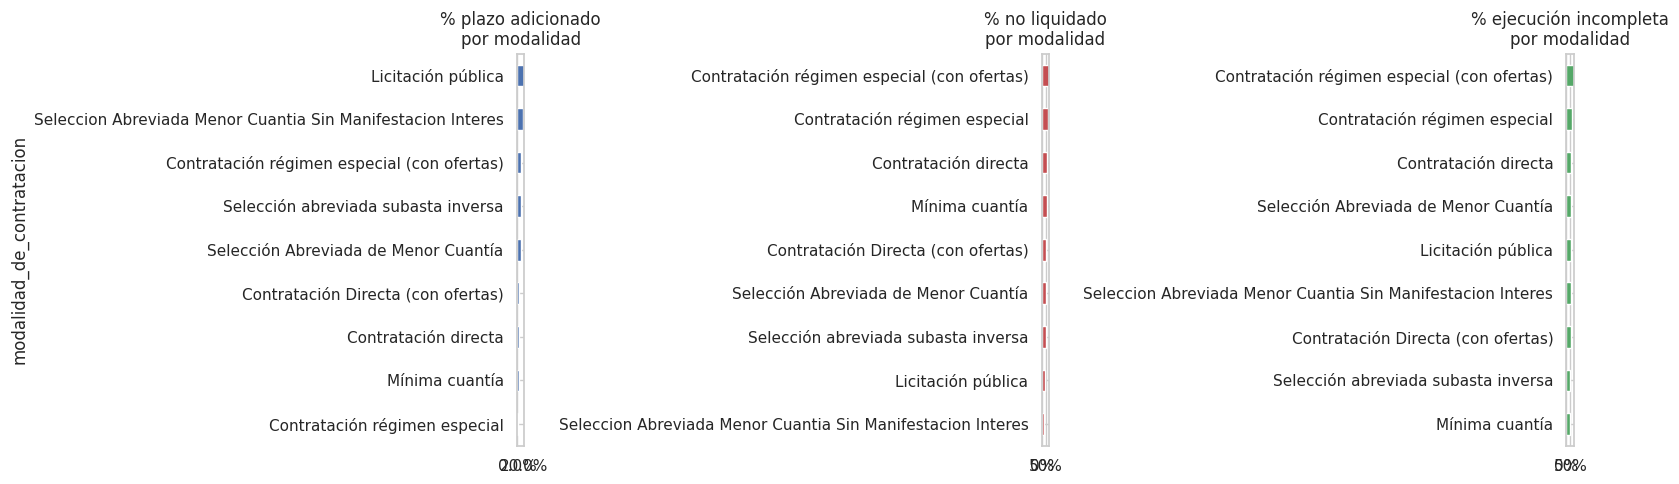

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=False)

tasa_mod_plazo = window.groupby('modalidad_de_contratacion')['plazo_adicionado'].mean().sort_values()
tasa_mod_plazo.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('% plazo adicionado\npor modalidad'); axes[0].set_xlabel('')

tasa_mod_liq = window_fin.groupby('modalidad_de_contratacion')['no_liquidado_tras_fin'].mean().sort_values()
tasa_mod_liq.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('% no liquidado\npor modalidad'); axes[1].set_ylabel(''); axes[1].set_xlabel('')

tasa_mod_ejec = window_fin.groupby('modalidad_de_contratacion')['ejecucion_incompleta'].mean().sort_values()
tasa_mod_ejec.plot(kind='barh', ax=axes[2], color='#55A868')
axes[2].set_title('% ejecución incompleta\npor modalidad'); axes[2].set_ylabel(''); axes[2].set_xlabel('')

for ax in axes:
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

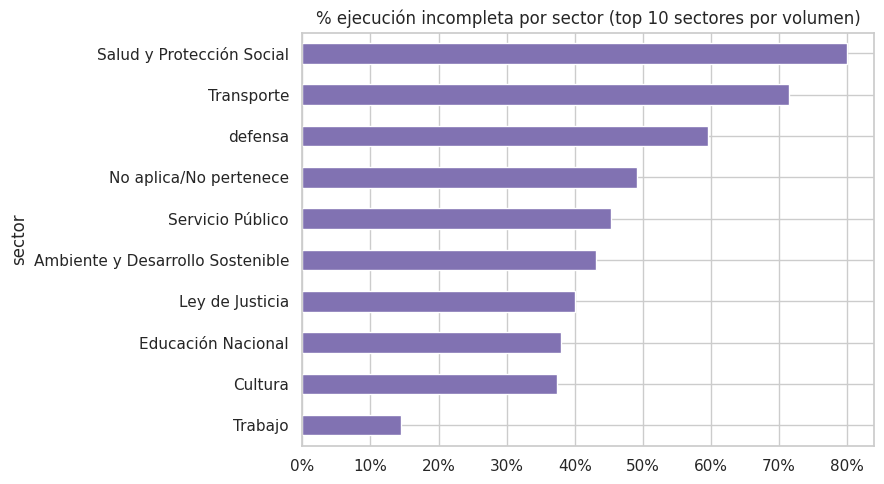

In [23]:
fig, ax = plt.subplots(figsize=(9,5))
top_sectores = window_fin['sector'].value_counts().head(10).index
sub = window_fin[window_fin['sector'].isin(top_sectores)]
tasa_sector = sub.groupby('sector')['ejecucion_incompleta'].mean().sort_values()
tasa_sector.plot(kind='barh', ax=ax, color='#8172B2')
ax.set_title('% ejecución incompleta por sector (top 10 sectores por volumen)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

/tmp/ipykernel_190/4054549065.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=['Con adición\nde plazo', 'Sin adición\nde plazo'], showfliers=False)


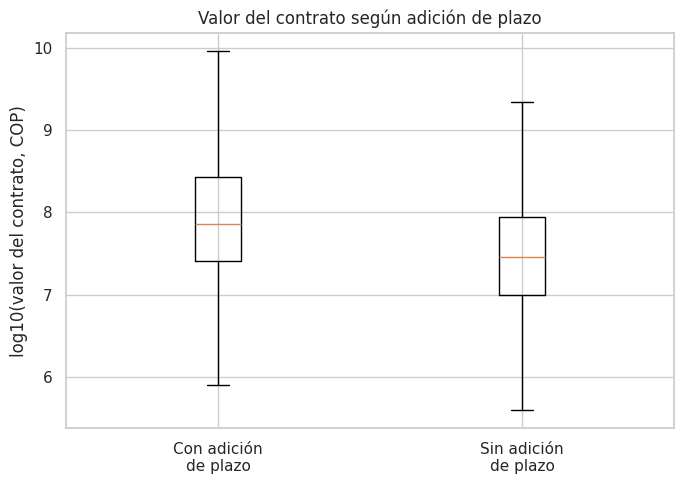

In [24]:
fig, ax = plt.subplots(figsize=(7,5))
box_data = [
    np.log10(window.loc[window['plazo_adicionado'], 'valor_del_contrato']),
    np.log10(window.loc[~window['plazo_adicionado'], 'valor_del_contrato']),
]
ax.boxplot(box_data, labels=['Con adición\nde plazo', 'Sin adición\nde plazo'], showfliers=False)
ax.set_ylabel('log10(valor del contrato, COP)')
ax.set_title('Valor del contrato según adición de plazo')
plt.tight_layout(); plt.show()

### 3.5 Resumen de resultados de las pruebas de hipótesis

In [25]:
resumen = pd.DataFrame(resultados)
resumen['significativo'] = resumen['p'] < 0.05
resumen['p'] = resumen['p'].apply(lambda x: f"{x:.2e}")
resumen['cramers_v'] = resumen['cramers_v'].round(3)
resumen[['label','p','significativo','cramers_v']]

,label,p,significativo,cramers_v
0,H1a — Modalidad de contratación vs. plazo adic...,0.00e+00,True,0.115
1,H1b — Sector vs. plazo adicionado,2.72e-149,True,0.081
2,H1c — Orden de la entidad (Nacional/Territoria...,4.09e-07,True,0.016
3,H2a — Modalidad de contratación vs. no liquida...,0.00e+00,True,0.195
4,H2b — Orden de la entidad vs. no liquidado tra...,6.49e-278,True,0.137
5,H2c — Destino del gasto vs. no liquidado tras ...,2.75e-113,True,0.088
6,H3a — Modalidad de contratación vs. ejecución ...,0.00e+00,True,0.193
7,H3b — Sector vs. ejecución incompleta,0.00e+00,True,0.340
8,H3c — Proveedor PyME vs. ejecución incompleta,1.39e-88,True,0.076
9,H6 — Pago adelantado habilitado vs. plazo adic...,9.11e-02,False,0.006


## 4. Generación de resultados (25%)

### Informe ejecutivo — Criterios de focalización de la supervisión

**Para:** Oficina de control interno
**De:** Consultoría de ciencia de datos
**Asunto:** Criterios basados en datos para priorizar la supervisión de contratos de compra de bienes

#### Contexto y alcance del análisis

Analizamos 196,391 contratos de compra de bienes (compraventa y suministros) firmados por entidades públicas colombianas entre 2019 y 2025, extraídos de SECOP II. Tras excluir registros con valores inválidos o inconsistencias de fecha (1.0% del total), y restringir los indicadores dependientes del cierre del contrato a los firmados entre 2019 y 2023 (para evitar sesgar el análisis con contratos que aún no han tenido tiempo de completar su ciclo de vida), trabajamos sobre una base de ~119,700 contratos.

#### Hallazgos clave

1. **La modalidad de contratación es, junto con el sector, el criterio más consistentemente asociado a los tres tipos de desviación.** Los contratos por **Licitación pública** y **selección abreviada** presentan hasta 3-4 veces más adiciones de plazo que **Mínima cuantía**. En contraste, **Contratación régimen especial (con ofertas)** es la modalidad con peor desempeño en cierre sin liquidar (88.1%) y en ejecución incompleta (89.2%) — el peor perfil combinado de todo el análisis.
2. **El sector administrativo es el factor con mayor poder explicativo sobre la ejecución presupuestal incompleta** (V de Cramér ≈ 0.34, el más alto de todo el estudio). Sectores como *Relaciones Exteriores* y *Minas y Energía* cierran casi siempre con ejecución incompleta, mientras que *Trabajo* casi nunca.
3. **Las entidades territoriales tienen una tasa de cierre sin liquidar mucho mayor que las nacionales** (67.5% vs. 53.7%), consistente con menor capacidad administrativa de cierre en el nivel territorial — un hallazgo accionable para programas de acompañamiento, no solo de sanción.
4. **El tamaño del contrato se comporta de forma distinta según el tipo de desviación**: los contratos grandes son más propensos a adición de plazo, pero los contratos *pequeños* son más propensos a quedar sin liquidar — hay que evitar el supuesto de que "solo los contratos grandes importan".
5. Los contratos de **Inversión** quedan sin liquidar más que los de **Funcionamiento** (63.8% vs. 56.3%), un hallazgo contraintuitivo dado el mayor escrutinio nominal sobre el gasto de inversión.
6. **No toda asociación estadísticamente significativa es operacionalmente relevante**: por ejemplo, si bien el género del representante legal del proveedor mostró una diferencia estadísticamente significativa (p<0.0001) en la tasa de no liquidación, la magnitud de la diferencia es mínima (57.7%-62.3%) y no se recomienda como criterio de focalización.

#### Criterios de focalización propuestos

Recomendamos que la oficina de control interno priorice el seguimiento **desde la firma del contrato** (no solo al detectar el problema) cuando se combine más de uno de estos factores:

- **Modalidad de alto riesgo:** Licitación pública, Selección abreviada (subasta inversa o menor cuantía) y Contratación en régimen especial — estas cuatro modalidades concentran las mayores tasas de desviación en al menos uno de los tres indicadores.
- **Sector de alto riesgo de ejecución incompleta:** Relaciones Exteriores, Minas y Energía, Salud y Protección Social, Ciencia y Tecnología, Industria y Transporte (todos con >70% de ejecución incompleta histórica).
- **Entidad territorial**, especialmente para el seguimiento del cierre/liquidación formal del contrato — foco de acompañamiento administrativo, no solo de control punitivo.
- **Contratos de bajo valor pero alto volumen** (mínima cuantía), donde el riesgo no es la adición de plazo sino el cierre sin liquidar — sugiere automatizar alertas de liquidación pendiente más que revisión manual caso a caso.
- **Destino de inversión**, dado el hallazgo contraintuitivo de mayor no-liquidación relativa a funcionamiento.

Un contrato que combine 2 o más de estos factores (ej. licitación pública + sector salud, o mínima cuantía + entidad territorial) debería recibir seguimiento proactivo desde el momento de la firma, sin esperar a que la desviación ya haya ocurrido.

#### Limitaciones del análisis

- **Confusión entre calidad del dato administrativo y desviación real del contrato.** No podemos distinguir con certeza si "no liquidado" refleja un problema de ejecución del contrato o simplemente un rezago en el diligenciamiento de SECOP II por parte de la entidad — la tasa de "finalizado" que se estanca entre 53%-60% incluso en años con tiempo de sobra para cerrar sugiere que parte del fenómeno es de reporte, no solo de ejecución.
- **Los indicadores de desviación son proxies, no medidas directas de sobrecosto o daño al ciudadano.** El taller pide asociar características del contrato con desviaciones "que suelen ser notificadas por los entes de control", pero el dataset no incluye hallazgos de auditoría ni sanciones — nuestras conclusiones son correlacionales, no causales.
- **El análisis de valor excluyó 385 contratos (0.2%) con valores inválidos o atípicos extremos**, que en la práctica podrían ser justamente los casos que más ameritan revisión manual prioritaria (posibles errores de digitación graves que ocultan contratos reales mal reportados).
- **Con muestras grandes, la significancia estadística es fácil de alcanzar aunque el efecto sea pequeño.** Mitigamos esto reportando el tamaño de efecto (V de Cramér), pero recomendamos validar los criterios propuestos con un piloto antes de institucionalizarlos como regla de asignación de supervisión.
- **No se incorporó información de series de tiempo/estacionalidad ni del historial del proveedor** (contratos repetidos, sanciones previas), variables que podrían mejorar sustancialmente la focalización pero no están en este dataset.
- **El umbral de 90% para "ejecución incompleta" es una decisión de diseño razonable pero arbitraria**; los resultados cualitativos (qué modalidad/sector es peor) se mantuvieron estables al probar con 80% y 95% como sensibilidad, pero las magnitudes exactas cambian.
